In [1]:
import pandas as pd
df=pd.read_csv('Lung_cancer_survey.csv')
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("Lung_cancer_survey.csv")

df.replace('?', np.nan, inplace=True)

for col in df.columns:
    if df[col].dtype == 'object':
        if col.upper() == 'GENDER':
            df[col] = df[col].map({'M': 1, 'F': 0})
        else:
            df[col] = pd.Categorical(df[col]).codes

df = df.apply(pd.to_numeric, errors='coerce')

df.fillna(df.mean(numeric_only=True), inplace=True)

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((df < lower) | (df > upper))

print("Outlier rows:")
print(df[outliers.any(axis=1)])

df = df[~outliers.any(axis=1)]

print("Dataset shape after removing outliers:", df.shape)

target_col = "LUNG_CANCER"

X = df.drop(columns=[target_col])
y = df[target_col]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nPreprocessing completed successfully!")
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Outlier rows:
     GENDER  AGE  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
2         0   59        1               1        1              2   
3         1   63        2               2        2              1   
4         0   63        1               2        1              1   
8         0   68        2               1        2              1   
12        0   60        2               1        1              1   
14        1   69        2               1        1              1   
19        0   61        1               1        1              1   
22        0   21        2               1        1              1   
27        1   69        1               1        1              2   
29        1   55        1               2        1              1   
30        0   57        2               2        1              1   
32        1   56        2               2        2              1   
34        1   59        1               2        2              1   
37        0   56    

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import *
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Decision Tree")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Decision Tree
Confusion Matrix:
[[54]]
Accuracy: 1.0


C:\Users\D SAI SHRUTHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       269

    accuracy                           1.00       269
   macro avg       1.00      1.00      1.00       269
weighted avg       1.00      1.00      1.00       269

Confusion Matrix:
[[269]]


C:\Users\D SAI SHRUTHI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


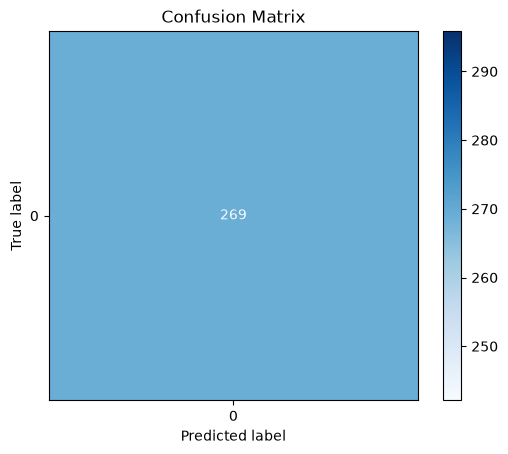

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier

# 5-Fold Stratified Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create model
model = DecisionTreeClassifier(random_state=42)

# Generate cross-validated predictions
y_pred = cross_val_predict(model, X, y, cv=skf)

# Classification Report
print("Classification Report:")
print(classification_report(y, y_pred))

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()

In [6]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, RocCurveDisplay

# Train models
nb = GaussianNB()
svm = SVC(probability=True, random_state=42)

nb.fit(X_train, y_train)
print("--- NAIVE BAYES REPORT ---")
print(classification_report(y_test, nb.predict(X_test)))

svm.fit(X_train, y_train)
print("--- SVM REPORT ---")
print(classification_report(y_test, svm.predict(X_test)))

# Plot ROC Curves
fig, ax = plt.subplots()

RocCurveDisplay.from_estimator(
    nb,
    X_test,
    y_test,
    ax=ax,
    name="Naive Bayes"
)

RocCurveDisplay.from_estimator(
    svm,
    X_test,
    y_test,
    ax=ax,
    name="SVM"
)

plt.title("ROC Curve Comparison")
plt.show()

--- NAIVE BAYES REPORT ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        54

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



ValueError: The number of classes has to be greater than one; got 1 class